In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings 
import numpy as np
warnings.filterwarnings("ignore")
df = pd.read_csv("C:/Users/braya/Downloads/M30 Online Retail.csv", encoding='unicode_escape')
df

,INVOICE_NO,STOCK_CODE,DESCRIPTION,QUANTITY,INVOICE_DATE,UNIT_PRICE,CUSTOMER_ID,REGION
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2019 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2019 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09/12/2020 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/2020 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/2020 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/2020 12:50,4.15,12680.0,France


In [9]:
from ydata_profiling import ProfileReport
reporte = ProfileReport(df, title="Reporte Mágico de mis Datos")
reporte.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:12<00:00,  1.56s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
df.isnull().mean()*100

INVOICE_NO       0.000000
STOCK_CODE       0.000000
DESCRIPTION      0.268311
QUANTITY         0.000000
INVOICE_DATE     0.000000
UNIT_PRICE       0.000000
CUSTOMER_ID     24.926694
REGION           0.000000
dtype: float64

In [13]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
QUANTITY,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UNIT_PRICE,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CUSTOMER_ID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [15]:
df.duplicated().sum()

5268

In [17]:
df_clean = df.dropna(subset=['CUSTOMER_ID'])
df_clean.isnull().mean()*100

INVOICE_NO      0.0
STOCK_CODE      0.0
DESCRIPTION     0.0
QUANTITY        0.0
INVOICE_DATE    0.0
UNIT_PRICE      0.0
CUSTOMER_ID     0.0
REGION          0.0
dtype: float64

In [19]:
df_clean = df_clean.drop_duplicates()
df_clean.duplicated().sum()

0

In [21]:
total_clientes = df_clean['CUSTOMER_ID'].nunique()

print(f"El número total de clientes únicos válidos es: {total_clientes}")

El número total de clientes únicos válidos es: 4372


In [31]:
df_clean['TOTAL_PRICE'] = df_clean['QUANTITY'] * df_clean['UNIT_PRICE']
df_clean['INVOICE_DATE'] = pd.to_datetime(df_clean['INVOICE_DATE'], dayfirst=True)

rfm = df_clean.groupby('CUSTOMER_ID').agg({
    'INVOICE_DATE': 'max',      
    'INVOICE_NO': 'nunique',    
    'TOTAL_PRICE': 'sum'        
}).reset_index()

rfm.columns = ['ID_Cliente', 'Ultima_Compra', 'Frecuencia', 'Valor_Monetario']

rfm.head()

,ID_Cliente,Ultima_Compra,Frecuencia,Valor_Monetario
0,12346.0,2020-01-18 10:17:00,2,0.00
1,12347.0,2020-12-07 15:52:00,7,4310.00
2,12348.0,2020-09-25 13:13:00,4,1797.24
3,12349.0,2020-11-21 09:51:00,1,1757.55
4,12350.0,2020-02-02 16:01:00,1,334.40


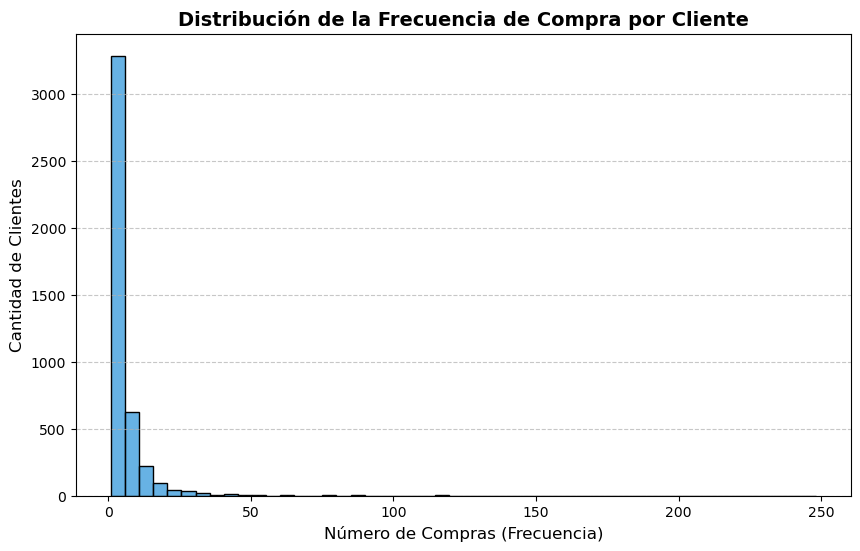

In [41]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.histplot(rfm['Frecuencia'], bins=50, color='#3498db', edgecolor='black')
plt.title('Distribución de la Frecuencia de Compra por Cliente', fontsize=14, fontweight='bold')
plt.xlabel('Número de Compras (Frecuencia)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [45]:
def order_cluster(cluster_field_name, target_field_name, rfm, ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = rfm.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    df_final = pd.merge(rfm,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

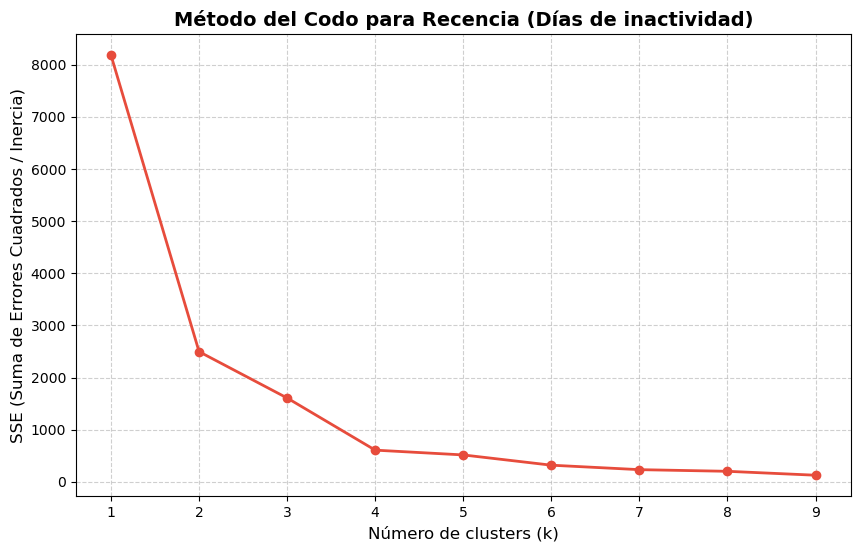

In [51]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

fecha_maxima = rfm['Ultima_Compra'].max() + pd.Timedelta(days=1)
rfm['Recencia'] = (fecha_maxima - rfm['Ultima_Compra']).dt.days
rfm['Recencia_Log'] = np.log1p(rfm['Recencia'])


sse = {}
recency = rfm[['Recencia_Log']].copy() 

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(recency)
    recency["clusters"] = kmeans.labels_
    sse[k] = kmeans.inertia_
    
plt.figure(figsize=(10,6))
plt.plot(list(sse.keys()), list(sse.values()), marker='o', linewidth=2, color='#e74c3c') 

plt.title('Método del Codo para Recencia (Días de inactividad)', fontsize=14, fontweight='bold')
plt.xlabel("Número de clusters (k)", fontsize=12)
plt.ylabel("SSE (Suma de Errores Cuadrados / Inercia)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [55]:

customer = rfm.rename(columns={
    'Ultima_Compra': 'LAST_PURCHASE',
    'Frecuencia': 'FREQUENCY',
    'Valor_Monetario': 'MONETARY'
}).copy()


fecha_maxima = customer['LAST_PURCHASE'].max() + pd.Timedelta(days=1)
customer['RECENCY'] = (fecha_maxima - customer['LAST_PURCHASE']).dt.days

customer['RECENCY_LOG'] = np.log1p(customer['RECENCY'])
customer['FREQUENCY_LOG'] = np.log1p(customer['FREQUENCY'])
customer['MONETARY_LOG'] = np.log1p(customer['MONETARY'])

In [65]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(customer[['RECENCY_LOG']])
customer['RECENCY_CLUSTER'] = kmeans.predict(customer[['RECENCY_LOG']])
customer = order_cluster('RECENCY_CLUSTER', 'RECENCY', customer, False)
print("--- RECENCY ---")
display(customer.groupby('RECENCY_CLUSTER')['RECENCY'].describe())



kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(customer[['FREQUENCY_LOG']])
customer['FREQUENCY_CLUSTER'] = kmeans.predict(customer[['FREQUENCY_LOG']])
customer = order_cluster('FREQUENCY_CLUSTER', 'FREQUENCY', customer, True)
print("\n--- FREQUENCY ---")
display(customer.groupby('FREQUENCY_CLUSTER')['FREQUENCY'].describe())



kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(customer[['MONETARY_LOG']])
customer['MONETARY_CLUSTER'] = kmeans.predict(customer[['MONETARY_LOG']])
customer = order_cluster('MONETARY_CLUSTER', 'MONETARY', customer, True)
print("\n--- MONETARY ---")
display(customer.groupby('MONETARY_CLUSTER')['MONETARY'].describe())

--- RECENCY ---


,count,mean,std,min,25%,50%,75%,max
RECENCY_CLUSTER,,,,,,,,
0,1183.0,233.906171,72.234405,122.0,172.0,227.0,289.00,375.0
1,1232.0,69.305195,22.209351,38.0,51.0,65.0,84.00,121.0
2,1185.0,21.964557,7.856854,10.0,16.0,22.0,29.00,37.0
3,730.0,4.641096,2.749727,1.0,2.0,4.0,7.75,9.0



--- FREQUENCY ---


,count,mean,std,min,25%,50%,75%,max
FREQUENCY_CLUSTER,,,,,,,,
0,1283.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
1,811.0,2.000000,0.000000,2.0,2.0,2.0,2.0,2.0
2,1502.0,4.440746,1.334777,3.0,3.0,4.0,5.0,7.0
3,734.0,17.098093,18.180426,8.0,9.0,12.0,18.0,248.0



--- MONETARY ---


,count,mean,std,min,25%,50%,75%,max
MONETARY_CLUSTER,,,,,,,,
0,829.0,143.543378,55.000820,0.00,107.600,149.64,187.290,232.03
1,1602.0,465.822393,157.825200,232.15,326.875,435.54,601.875,795.12
2,1347.0,1546.858129,579.371919,797.32,1045.195,1405.78,1958.350,2929.84
3,552.0,9679.140817,21516.903681,2935.80,3625.845,4804.05,7573.360,279489.02


In [63]:
customer = customer[customer['MONETARY'] >= 0].copy()
customer = customer.dropna(subset=['MONETARY'])
customer['MONETARY_LOG'] = np.log1p(customer['MONETARY'])
print("Peligro de NaNs restante:", customer['MONETARY_LOG'].isnull().sum())

Peligro de NaNs restante: 0


In [67]:
customer['SCORE'] = customer['RECENCY_CLUSTER'] + customer['FREQUENCY_CLUSTER'] + customer['MONETARY_CLUSTER']
resumen_score = customer.groupby('SCORE')[['RECENCY', 'FREQUENCY', 'MONETARY']].mean()

resumen_score

,RECENCY,FREQUENCY,MONETARY
SCORE,,,
0,259.540230,1.000000,139.763046
1,190.746450,1.141988,277.155314
2,120.438163,1.461131,395.883853
3,97.519455,2.128405,543.913054
4,73.562368,2.959831,757.364484
5,52.045802,4.076336,1207.088954
6,29.314815,5.501852,1636.358759
7,18.261236,7.668539,2576.408034
8,12.183673,13.503401,5490.291259


In [69]:
def segment(score):
    if score <= 1:
        return 'Low-Value'
    elif score <= 4: 
        return 'Average'
    elif score <= 6:
        return 'Potential'
    else:
        return 'High-Value'

customer['SEGMENT'] = customer['SCORE'].apply(segment)
print(customer['SEGMENT'].value_counts())

SEGMENT
Average       1553
Potential     1064
High-Value     872
Low-Value      841
Name: count, dtype: int64


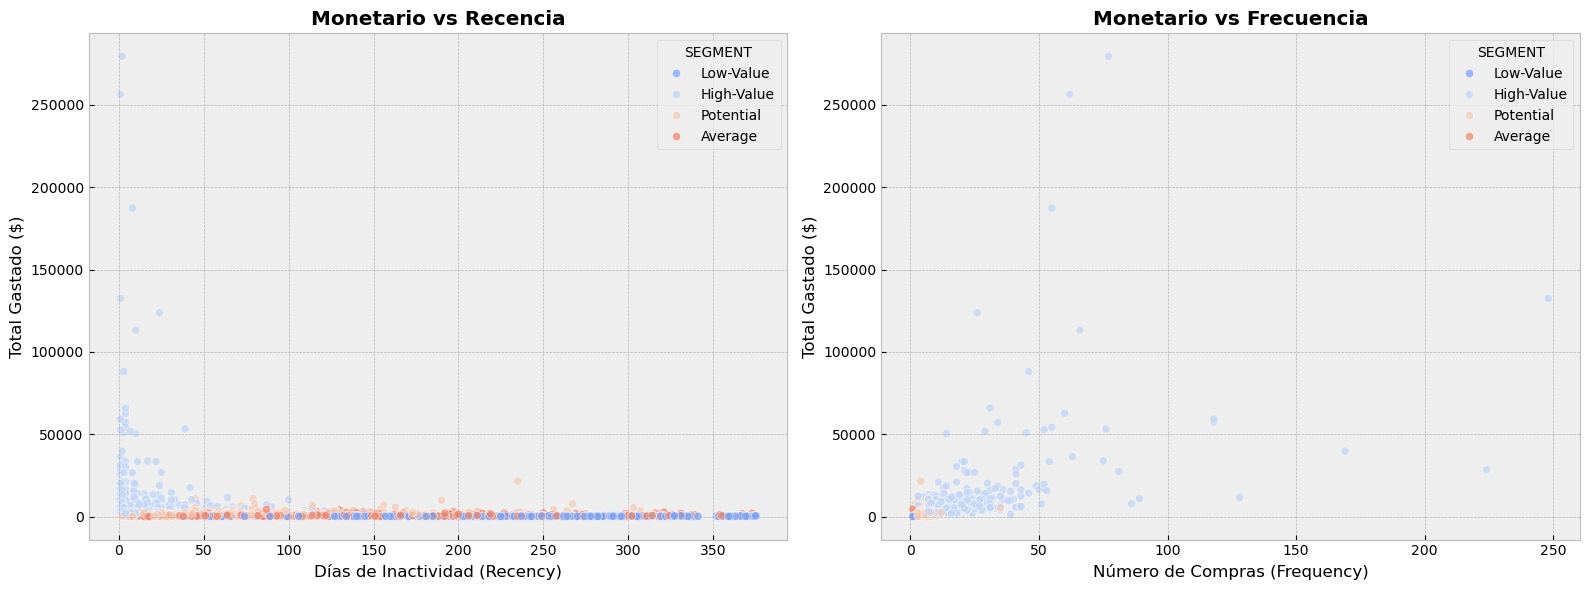

In [73]:
plt.style.use('bmh')
customer_filtrado = customer[customer['RECENCY'] < 4000]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=customer_filtrado, 
    x='RECENCY', 
    y='MONETARY', 
    hue='SEGMENT',
    palette='coolwarm',
    alpha=0.7, 
    ax=axes[0] 
)
axes[0].set_title('Monetario vs Recencia', fontweight='bold')
axes[0].set_xlabel('Días de Inactividad (Recency)')
axes[0].set_ylabel('Total Gastado ($)')


sns.scatterplot(
    data=customer_filtrado, 
    x='FREQUENCY', 
    y='MONETARY', 
    hue='SEGMENT',
    palette='coolwarm',
    alpha=0.7,
    ax=axes[1] 
)
axes[1].set_title('Monetario vs Frecuencia', fontweight='bold')
axes[1].set_xlabel('Número de Compras (Frequency)')
axes[1].set_ylabel('Total Gastado ($)')


plt.tight_layout()
plt.show()